# Notebook 06 — Modelagem e Análise de Entropia

**Projeto:** Mineração de Dados em Saúde · PNS 2019
**Estudo:** Artrite e Reumatismo em Idosos Brasileiros
**Pesquisador:** Pedro Dias Soares
**Orientador:** Prof. Dr. Luis Enrique Zárate — PUC Minas (LICAP)

---

## O que este notebook faz (estado atual)

Implementa a **Análise de Entropia** (§3) sobre os datasets discretizados (saída do NB04), nos
**dois desenhos** (artrite pura · artrite + comorbidades). As seções de **modelagem** (modelos,
CV, comparação estatística, interpretabilidade) seguem o esqueleto de `proxima_fase.md` §2 e
entram em seguida — esta entrega consome o conjunto de atributos **selecionado pela entropia**.

## Metodologia de entropia (slides + artigos do orientador)

Os slides *Introdução15 (Entropia)* e *Introdução16 (Similaridade)* trazem **três usos** de
entropia: **(A)** entropia univariada H(X) para detectar atributo quase-constante; **(B)** poder
classificatório / **ganho de informação** IG = H(C)−H(C|A) para ranquear atributos *vs.* a classe;
**(C)** entropia de similaridade (Gower + Dash–Liu) para remover subconjuntos redundantes.

Dos 6 artigos do LICAP sobre a PNS, **nenhum** usou (C). O *paper-irmão* deste estudo
— **Artrite + Depressão (SBBD 2025)** — calculou a entropia *em relação à variável de classe*
(uso B) e, como os valores ficaram próximos, **manteve todos** os atributos; o de **Depressão**
removeu só 3 atributos degenerados (uso A). Seguimos o uso **(B)** como núcleo.

**Decisões fixadas para o NB06:**

| Decisão | Valor | Motivo |
|---|---|---|
| Camada de entropia | **1 — ranking supervisionado** (IG · Gain Ratio · **Incerteza Simétrica / SU**) | = art_d; SU normaliza a cardinalidade (atributos têm 2–22 níveis) |
| Papel | **Seleção** (remove atributos) | = art_c |
| Regra de corte | **Conservadora**: remove só **SU < `limiar_su`** (≈0 = sem informação de classe) | A base tem associação fraca (igual aos papers); cortar por significância removeria ~90% — indefensável |
| Base da medida | **Treino balanceado (RUS)** | No D1 (8,77:1) o desbalanceamento esmaga H(C)=0,48 e o IG; balancear traz H(C)≈1 e torna D1×D2 comparáveis |
| Permutação | **Coluna descritiva** (p-valor), **não** gatilho de remoção | Mostra honestamente que o sinal é fraco (ecoa art_d/art_b) |
| Vazamento | Seleção ajustada **só no treino** (teste *held-out*) | Padrão do projeto (cf. mediana in-fold do NB04) |

> Convenção de cor: <span style="color:#C0392B">**vermelho = Com Artrite**</span>,
> <span style="color:#27AE60">**verde = Saudável**</span>.

## 1 · Configuração

Lê o `config.toml` (fonte única). Os parâmetros da entropia estão na seção `[modelagem]`:
`test_size`, `limiar_su` (corte da seleção), `n_perm` (permutações) e `top_n_fig`. Os dois
desenhos apontam para o `dataset_discretizado.csv` de cada pasta do NB04; a saída vai para
`data/results/modelagem/`.

In [1]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

for _cat in (FutureWarning, DeprecationWarning, UserWarning):  # silencia avisos de depreciação (pandas/seaborn)
    warnings.filterwarnings('ignore', category=_cat)

# ── Configuração central (config.toml — fonte única) ──
try:
    import tomllib                       # Python 3.11+ (stdlib)
except ModuleNotFoundError:
    import tomli as tomllib              # Python 3.10: pip install tomli
with open('../config.toml', 'rb') as _f:
    CFG = tomllib.load(_f)

RANDOM_STATE = CFG['pipeline']['random_state']
ALPHA        = CFG['pipeline']['alpha']
MOD          = CFG['modelagem']
TEST_SIZE, LIMIAR_SU = MOD['test_size'], MOD['limiar_su']
N_PERM, TOP_N_FIG    = MOD['n_perm'], MOD['top_n_fig']
COR_ARTRITE  = CFG['cores']['artrite']    # vermelho
COR_SAUDAVEL = CFG['cores']['saudavel']   # verde

# ── Os dois desenhos: entrada = saída discretizada do NB04 ──
DESENHOS = {
    'd1': {'rotulo': 'Desenho 1 — Artrite pura',
           'entrada': '../data/results/discretizacao/dataset_discretizado.csv'},
    'd2': {'rotulo': 'Desenho 2 — Artrite + comorbidades',
           'entrada': '../data/results/discretizacao_comorbidades/dataset_discretizado.csv'},
}
DIR_SAIDA = '../data/results/modelagem/'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

def preparar_dirs(saida):
    figs, tabs = saida + 'figuras/', saida + 'tabelas/'
    for p in (saida, figs, tabs):
        os.makedirs(p, exist_ok=True)
    return figs, tabs

def salvar_fig(figs, nome):
    plt.savefig(figs + nome, dpi=150, bbox_inches='tight'); print(f'  \u2705 Figura \u2192 {figs+nome}')

def salvar_tab(tabs, df, nome):
    df.to_csv(tabs + nome, encoding='utf-8-sig');           print(f'  \u2705 Tabela \u2192 {tabs+nome}')

DIR_FIGURAS, DIR_TABELAS = preparar_dirs(DIR_SAIDA)
print(f'\u2705 Ambiente configurado. RANDOM_STATE={RANDOM_STATE}, ALPHA={ALPHA}')
print(f'   Seleção por entropia: limiar_su={LIMIAR_SU}, n_perm={N_PERM}, test_size={TEST_SIZE}')
print(f'   Saída: {DIR_SAIDA}')

✅ Ambiente configurado. RANDOM_STATE=42, ALPHA=0.05
   Seleção por entropia: limiar_su=0.001, n_perm=200, test_size=0.2
   Saída: ../data/results/modelagem/


## 2 · Carregamento e split 80/20 estratificado

Cada desenho é lido e dividido em treino/teste **estratificado** por classe (`random_state=42`).
A entropia é medida **só no treino** — o teste fica intocado (*held-out*), evitando vazamento na
etapa de seleção de atributos.

In [2]:
from sklearn.model_selection import train_test_split

DADOS = {}
for nome, cfg in DESENHOS.items():
    assert os.path.exists(cfg['entrada']), (
        f"Arquivo não encontrado: {cfg['entrada']}. Rode o NB04 (discretização) antes, "
        "ou copie data/results/ do repositório principal (é gitignored).")
    df = pd.read_csv(cfg['entrada'])
    y  = df['Label'].astype(int)
    X  = df.drop(columns=['Label']).copy()
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    DADOS[nome] = dict(Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, p=X.shape[1])
    print(f"[{nome}] {cfg['rotulo']}: {df.shape[0]:,}\u00d7{X.shape[1]}  "
          f"| treino {len(ytr):,} (0/1={dict(ytr.value_counts())}) "
          f"| teste {len(yte):,}")

[d1] Desenho 1 — Artrite pura: 4,826×59  | treino 3,860 (0/1={0: 3465, 1: 395}) | teste 966
[d2] Desenho 2 — Artrite + comorbidades: 8,357×56  | treino 6,685 (0/1={0: 3465, 1: 3220}) | teste 1,672


## 3 · Análise de Entropia (núcleo)

Mede, para cada atributo discretizado, **quanta incerteza da classe ele reduz**:

- **H(C)** — entropia da classe (em *bits*, log₂).
- **H(C|A)** = Σₐ P(a)·H(C|A=a) — entropia condicional.
- **IG(A)** = H(C) − H(C|A) — ganho de informação (= informação mútua).
- **Gain Ratio** = IG / H(A) — normaliza pela entropia do próprio atributo (Quinlan).
- **SU** = 2·IG / (H(C)+H(A)) ∈ [0,1] — **Incerteza Simétrica**: métrica primária, justa
  entre atributos de cardinalidades diferentes (aqui de 2 a 22 níveis).

Tudo medido sobre o **treino balanceado por RUS** (para H(C)≈1 e D1×D2 comparáveis). A coluna
`p_perm` (permutação de y) é **descritiva**: indica se a SU observada supera o acaso — mas a
remoção usa **apenas** o corte conservador `SU < limiar_su`.

### 3.1 · Funções de entropia

In [3]:
def entropia_shannon(serie):
    # H(X) em bits (log2). Mesma definição do NB04.
    p = pd.Series(np.asarray(serie)).value_counts(normalize=True, dropna=True)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def entropia_condicional(y, a):
    # H(C|A) = soma_a P(a) * H(C | A=a). NaN do atributo vira uma categoria própria.
    df = pd.DataFrame({'y': np.asarray(y), 'a': pd.Series(np.asarray(a)).where(pd.notna(np.asarray(a)), 'NA__')})
    tot = len(df); h = 0.0
    for _, g in df.groupby('a', observed=True):
        h += (len(g) / tot) * entropia_shannon(g['y'])
    return h

def metricas_entropia(X, y):
    # Retorna DataFrame com IG, Gain Ratio e SU por atributo (ordenado por SU desc).
    Hc = entropia_shannon(y); rows = []
    for c in X.columns:
        a  = X[c]
        Ha = entropia_shannon(a)
        ig = Hc - entropia_condicional(y, a)
        gr = ig / Ha if Ha > 0 else 0.0
        su = 2 * ig / (Hc + Ha) if (Hc + Ha) > 0 else 0.0
        rows.append({'feature': c, 'k': int(pd.Series(a).nunique(dropna=True)),
                     'H_A': round(Ha, 3), 'IG': round(ig, 4),
                     'GainRatio': round(gr, 4), 'SU': round(su, 4)})
    return Hc, pd.DataFrame(rows).sort_values('SU', ascending=False).reset_index(drop=True)

def undersample(X, y, seed=RANDOM_STATE):
    # RUS: subamostra aleatória da(s) classe(s) maioritária(s) até o tamanho da minoritária.
    # (As seções de modelagem usarão imblearn.RandomUnderSampler in-fold dentro da CV.)
    rng = np.random.default_rng(seed)
    y = pd.Series(np.asarray(y), index=X.index)
    n = int(y.value_counts().min()); idx = []
    for cls in sorted(y.unique()):
        ci = y.index[y == cls].to_numpy()
        idx.append(rng.choice(ci, n, replace=False))
    idx = np.concatenate(idx)
    return X.loc[idx], y.loc[idx]

def pvalor_permutacao(X, y, su_obs, n_perm=N_PERM, seed=RANDOM_STATE):
    # p-valor descritivo por atributo: fração de permutações de y cuja SU >= SU observada.
    rng = np.random.default_rng(seed)
    yv = np.asarray(y)
    ge = pd.Series(0, index=su_obs.index, dtype=float)
    for _ in range(n_perm):
        _, t = metricas_entropia(X, rng.permutation(yv))
        su_p = t.set_index('feature')['SU'].reindex(su_obs.index).fillna(0.0)
        ge += (su_p.values >= su_obs.values).astype(float)
    return ((ge + 1) / (n_perm + 1)).round(4)   # +1: estimador conservador de p

print('  \u2705 Funções de entropia definidas.')

  ✅ Funções de entropia definidas.


### 3.2 · Ranking e seleção por desenho

Para cada desenho: balanceia o treino (RUS), calcula as métricas, anexa o `p_perm` descritivo e
aplica o corte conservador. `decisao = 'remover'` ⇔ `SU < limiar_su`. O conjunto **mantido**
(`features_selecionadas`) é o que alimenta a modelagem.

In [4]:
RESULT = {}
for nome, cfg in DESENHOS.items():
    Xtr, ytr = DADOS[nome]['Xtr'], DADOS[nome]['ytr']
    Hc_nat   = entropia_shannon(ytr)                 # H(C) na distribuição natural (desbalanceada)
    Xb, yb   = undersample(Xtr, ytr)                 # treino balanceado (RUS)
    Hc_bal, tab = metricas_entropia(Xb, yb)          # métricas sobre o treino balanceado
    tab['p_perm']       = pvalor_permutacao(Xb, yb, tab.set_index('feature')['SU']).values
    tab['significativo'] = tab['p_perm'] < ALPHA
    tab['decisao']       = np.where(tab['SU'] < LIMIAR_SU, 'remover', 'manter')

    mantidas = tab.loc[tab.decisao == 'manter', 'feature'].tolist()
    removidas = tab.loc[tab.decisao == 'remover', 'feature'].tolist()
    RESULT[nome] = dict(Hc_nat=Hc_nat, Hc_bal=Hc_bal, n_bal=len(yb),
                        tabela=tab, mantidas=mantidas, removidas=removidas)

    print(f"\n\u2550\u2550 [{nome}] {cfg['rotulo']} \u2550\u2550")
    print(f"   H(Classe): natural={Hc_nat:.3f}  |  balanceada(RUS)={Hc_bal:.3f} bits  (n_bal={len(yb):,})")
    print(f"   Mantidos: {len(mantidas)}  |  Removidos (SU<{LIMIAR_SU}): {len(removidas)}")
    print(f"   Significativos vs. acaso (p<{ALPHA}): {int(tab['significativo'].sum())}/{len(tab)}")
    salvar_tab(DIR_TABELAS, tab.set_index('feature'), f'entropia_ranking_{nome}.csv')
    print('   Removidos:', removidas)
    display(tab.head(12))


══ [d1] Desenho 1 — Artrite pura ══
   H(Classe): natural=0.476  |  balanceada(RUS)=1.000 bits  (n_bal=790)
   Mantidos: 39  |  Removidos (SU<0.001): 20
   Significativos vs. acaso (p<0.05): 16/59
  ✅ Tabela → ../data/results/modelagem/tabelas/entropia_ranking_d1.csv
   Removidos: ['P02101_Normal', 'J01101_Mais de 2 anos a 3 anos', 'P00615_Sim', 'P034_Sim', 'P02401_Integral', 'G062_Não', 'P02601_Alto', 'P02801_cat', 'P013_cat', 'P02601_Baixo', 'P027_Uma vez ou mais por mês', 'P03201_Não', 'P02601_Muito alto', 'J01002_Outro serviço', 'J01002_Farmácia', 'J01002_Atendimento domiciliar', 'P00614_Sim', 'P00612_Sim', 'P02101_Diet/Light/Zero', 'P00620_Sim']


,feature,k,H_A,IG,GainRatio,SU,p_perm,significativo,decisao
0,Q084_Sim,2,0.850,0.0304,0.0358,0.0329,0.0050,True,manter
1,N010,4,1.368,0.0373,0.0273,0.0315,0.0050,True,manter
2,C006_Mulher,2,0.995,0.0308,0.0309,0.0308,0.0050,True,manter
3,N011,4,1.076,0.0300,0.0279,0.0289,0.0050,True,manter
4,N001,5,1.733,0.0311,0.0179,0.0227,0.0050,True,manter
5,G081,4,0.783,0.0199,0.0254,0.0223,0.0050,True,manter
6,J012_cat,4,1.831,0.0287,0.0157,0.0203,0.0050,True,manter
7,Q05901,6,2.099,0.0288,0.0137,0.0186,0.0050,True,manter
8,J01101_Mais de 1 ano a 2 anos,2,0.457,0.0106,0.0233,0.0146,0.0050,True,manter
9,J01002_Unidade básica de saúde (posto ou centr...,2,0.952,0.0096,0.0101,0.0098,0.0050,True,manter



══ [d2] Desenho 2 — Artrite + comorbidades ══
   H(Classe): natural=0.999  |  balanceada(RUS)=1.000 bits  (n_bal=6,440)
   Mantidos: 43  |  Removidos (SU<0.001): 13
   Significativos vs. acaso (p<0.05): 44/56
  ✅ Tabela → ../data/results/modelagem/tabelas/entropia_ranking_d2.csv
   Removidos: ['G062_Não', 'J01002_Policlínica pública, PAM (Posto de Assistência Médica) ou Centro de Especialidades público', 'VDF004', 'P00615_Sim', 'J01002_UPA (Unidade de Pronto Atendimento), outro tipo de pronto atendimento público (24 horas), pronto-socorro ou emergência de hospital público.', 'P02602_cat', 'P02601_Muito alto', 'J01002_Farmácia', 'J01002_Atendimento domiciliar', 'P034_Sim', 'P02401_Os dois tipos', 'P02601_Alto', 'J01002_Outro serviço']


,feature,k,H_A,IG,GainRatio,SU,p_perm,significativo,decisao
0,C006_Mulher,2,0.969,0.0997,0.1029,0.1013,0.005,True,manter
1,J012_cat,4,1.885,0.1412,0.0749,0.0979,0.005,True,manter
2,Q084_Sim,2,0.931,0.0946,0.1015,0.0979,0.005,True,manter
3,N001,5,1.849,0.1303,0.0704,0.0914,0.005,True,manter
4,N011,4,1.424,0.0979,0.0688,0.0808,0.005,True,manter
5,N010,4,1.603,0.0964,0.0601,0.0740,0.005,True,manter
6,G081,4,0.975,0.0665,0.0682,0.0673,0.005,True,manter
7,J01101_Mais de 3 anos,2,0.347,0.0325,0.0938,0.0483,0.005,True,manter
8,J01101_Mais de 1 ano a 2 anos,2,0.398,0.0269,0.0677,0.0385,0.005,True,manter
9,G062_Sim,2,0.328,0.0237,0.0723,0.0358,0.005,True,manter


### 3.3 · Figura — ranking por Incerteza Simétrica (top-N)

  ✅ Figura → ../data/results/modelagem/figuras/entropia_ranking_su.png


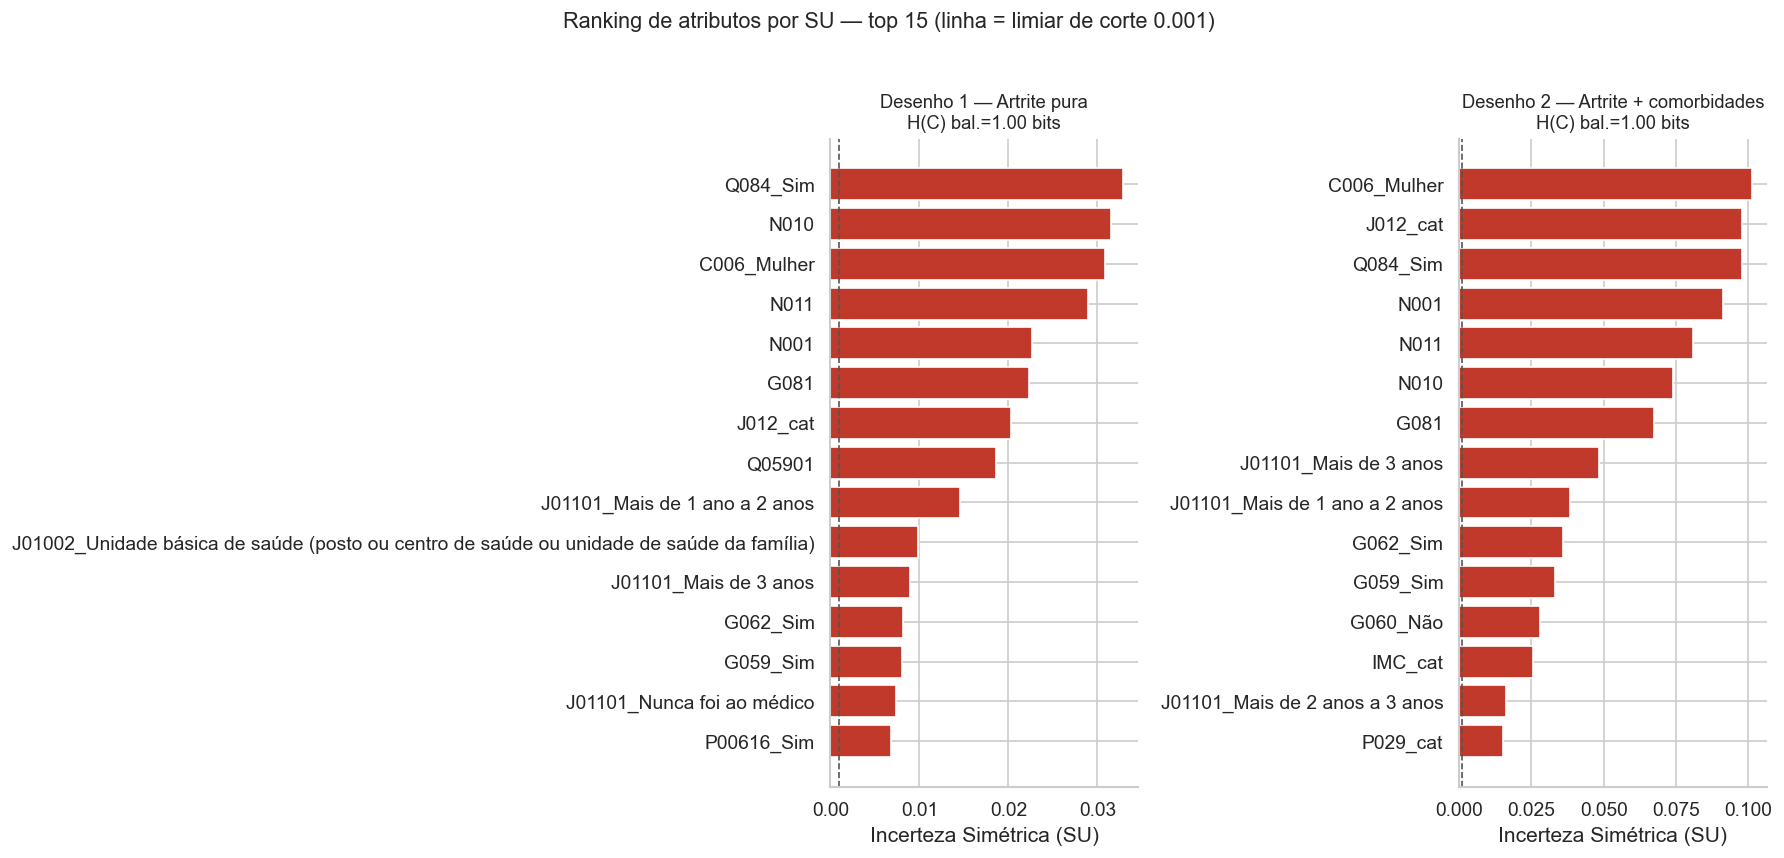

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (nome, cfg) in zip(axes, DESENHOS.items()):
    tab = RESULT[nome]['tabela'].head(TOP_N_FIG).iloc[::-1]
    cores = np.where(tab['decisao'] == 'manter', COR_ARTRITE, '#BBBBBB')
    ax.barh(tab['feature'], tab['SU'], color=cores)
    ax.axvline(LIMIAR_SU, ls='--', lw=1, color='#555555')
    ax.set_title(f"{cfg['rotulo']}\nH(C) bal.={RESULT[nome]['Hc_bal']:.2f} bits", fontsize=11)
    ax.set_xlabel('Incerteza Simétrica (SU)')
fig.suptitle(f'Ranking de atributos por SU — top {TOP_N_FIG} (linha = limiar de corte {LIMIAR_SU})',
             fontsize=13, y=1.02)
plt.tight_layout()
salvar_fig(DIR_FIGURAS, 'entropia_ranking_su.png')
plt.show()

### 3.4 · Exportação do relatório de entropia

In [6]:
relatorio = {
    'notebook': '06_modelagem_ml — Análise de Entropia',
    'pesquisador': 'Pedro Dias Soares',
    'orientador': 'Prof. Dr. Luis Enrique Zárate — PUC Minas',
    'metodo': ('Camada 1 (ranking supervisionado IG/GainRatio/SU, = art_d) com seleção '
               'conservadora (= art_c): remove SU<limiar_su sobre o treino balanceado por RUS; '
               'permutação como p-valor descritivo. Seleção ajustada só no treino.'),
    'parametros': {'RANDOM_STATE': RANDOM_STATE, 'ALPHA': ALPHA, 'TEST_SIZE': TEST_SIZE,
                   'LIMIAR_SU': LIMIAR_SU, 'N_PERM': N_PERM},
    'desenhos': {}}
for nome, cfg in DESENHOS.items():
    r = RESULT[nome]
    relatorio['desenhos'][nome] = {
        'rotulo': cfg['rotulo'],
        'H_classe_natural': round(r['Hc_nat'], 4),
        'H_classe_balanceada': round(r['Hc_bal'], 4),
        'n_treino_balanceado': int(r['n_bal']),
        'n_mantidos': len(r['mantidas']), 'n_removidos': len(r['removidas']),
        'features_selecionadas': r['mantidas'], 'features_removidas': r['removidas'],
        'ranking': r['tabela'].to_dict('records')}
with open(DIR_SAIDA + 'relatorio_entropia.json', 'w', encoding='utf-8') as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)
print(f'  \u2705 Relatório \u2192 {DIR_SAIDA}relatorio_entropia.json')

# Conjuntos prontos para a modelagem:
features_selecionadas = {nome: RESULT[nome]['mantidas'] for nome in DESENHOS}
print('  Atributos para a modelagem:',
      {k: len(v) for k, v in features_selecionadas.items()})

  ✅ Relatório → ../data/results/modelagem/relatorio_entropia.json
  Atributos para a modelagem: {'d1': 39, 'd2': 43}


## 4 · Próximos passos — Modelagem (a implementar)

A entropia entrega `features_selecionadas['d1' | 'd2']` para as próximas seções, conforme o
esqueleto de `proxima_fase.md` §2:

1. **Pipeline com RUS in-fold** (`imblearn.Pipeline`: `RandomUnderSampler → modelo`) — aplicado
   **só no treino, dentro de cada fold** da CV (evita vazamento; o teste permanece desbalanceado).
   > ⚠️ `imblearn` ainda **não está instalado** — `pip install imbalanced-learn`.
   >
   > ⚠️ **Vazamento treino/teste herdado do upstream (resolver AQUI).** Três transformações foram
   > ajustadas na **base inteira** antes do split: a **imputação** média/moda (NB03/03b, Etapa 8),
   > a **mediana** dos eixos do `Padrao_Alimentar_cat` (NB04, plano cartesiano) e a **mediana**
   > usada na imputação das features de engenharia (IMC/escores). Todas são *target-blind*, mas
   > vazam a distribuição do conjunto de teste. No pipeline de CV, **reajuste cada uma
   > _in-fold_ (estimada só no treino do fold)** — idealmente via `ColumnTransformer`/transformer
   > custom dentro do `imblearn.Pipeline`, junto com o RUS. O dataset persistido (NB04/05) segue
   > servindo à análise descritiva e à seleção por entropia (medida só no treino — sem vazamento).
2. **Modelos:** Regressão Logística (baseline interpretável) · Árvore de Decisão (regras) ·
   Random Forest (desempenho). Opcionais: Naïve-Bayes · AdaBoost · MLP.
3. **Otimização:** `RandomizedSearchCV(cv=StratifiedKFold(5), scoring='f1_macro', n_iter=30)`.
4. **Avaliação:** 10-fold CV no treino (Acc, Precision, Recall, F1-macro, AUC) — Média ± IC 95%;
   depois no teste *held-out* (matriz de confusão, ROC, classification report).
5. **Comparação estatística:** teste-t pareado nos 10 folds + correção de Bonferroni.
6. **Interpretabilidade:** `feature_importances` (Gini/MDI) × coeficientes da Logística (OR + IC) —
   **cruzar com o ranking de SU desta seção** (checagem independente do modelo) e com os fatores
   do art_d (sexo, diabetes, autopercepção de saúde). Agrupar por dimensão CAPTO.
7. **Comparação dos dois desenhos** e **exportação** dos artefatos em `data/results/modelagem/`.